# Probabilistic Power System Planning

## Course Information

- **Course**: SET3065 – Intelligent Electrical Power Grid  
- **University**: Delft University of Technology (TU Delft)  
- **Instructor**: Prof. Dr. Pedro P. Vergara  
- **Teaching Assistant**: Weijie Xia  


# Introduction

In recent years, **probabilistic power system planning** has garnered increasing interest, particularly as the power grid grows in complexity due to factors such as distributed generation, renewable integration, and evolving load patterns. The need for **stochastic modeling** of loads and generation sources is evident: static, deterministic models often fail to capture the highly variable and uncertain nature of modern power systems.

To address these challenges, **Generative AI** methods have emerged as promising tools. By leveraging statistical models—especially **Gaussian Mixture Models (GMMs)**—and **high-dimensional Gaussian distributions**, system planners can more effectively represent the range of possible load scenarios and the probabilistic nature of power flow outcomes. This approach not only provides insights into normal operating conditions but also illuminates potential **risk areas** and **voltage stability** concerns that might arise under less common, high-stress conditions.

In this assignment, we will use the **IEEE 33-bus system** as our case study. The workflow includes:

1. Generating synthetic bus loads from **high-dimensional Gaussian distributions**.
2. **Fitting Gaussian Mixture Models (GMMs)** to capture multimodal load behavior.
3. Conducting **probabilistic power flow analyses** by sampling from these GMMs.
4. Investigating the impact of **increasing total daily consumption** on voltage stability.


In [ ]:
!pip install pandapower -q
!pip install power-grid-model -q
!pip install power_grid_model_io -q

In [1]:
##########################
# IMPORTS AND SETUP
##########################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandapower as pp
import pandapower.networks as pn
from power_grid_model_io.converters import PandaPowerConverter

from sklearn.mixture import GaussianMixture
from power_grid_model import PowerGridModel

##########################
# CREATE THE IEEE 33-BUS NETWORK IN PANDAPOWER
##########################
net = pn.case33bw()
pp.runpp(net)
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.000000,0.000000,-3.917677,-2.435141
1,0.997032,0.014481,0.100000,0.060000
2,0.982938,0.096042,0.090000,0.040000
3,0.975456,0.161651,0.120000,0.080000
4,0.968059,0.228285,0.060000,0.030000
5,0.949658,0.133853,0.060000,0.020000
6,0.946173,-0.096474,0.200000,0.100000
7,0.941328,-0.060403,0.200000,0.100000
8,0.935059,-0.133485,0.060000,0.020000
9,0.929244,-0.196014,0.060000,0.020000


In [2]:
################################################
# Convert pandapower network to PowerGridModel
################################################
converter = PandaPowerConverter()
input_data_pgm, extra_info = converter.load_input_data(net)
input_data_pgm['line']['tan1'] = 0.0  # Assign 0 to tan1

# Create a network of power grid model
pgm = PowerGridModel(input_data=input_data_pgm, system_frequency=50.0)

# Run power flow
output_pgm = pgm.calculate_power_flow()
pd.DataFrame(output_pgm['node'])

,id,energized,u_pu,u,u_angle,p,q
0,0,1,0.999719,12656.436918,-0.000366,3.917809e+06,2.435229e+06
1,1,1,0.996750,12618.853459,-0.000113,-1.000000e+05,-6.000000e+04
2,2,1,0.982651,12440.362880,0.001312,-9.000000e+04,-4.000000e+04
3,3,1,0.975167,12345.615122,0.002457,-1.200000e+05,-8.000000e+04
4,4,1,0.967767,12251.935939,0.003621,-6.000000e+04,-3.000000e+04
5,5,1,0.949360,12018.901527,0.001972,-6.000000e+04,-2.000000e+04
6,6,1,0.945874,11974.759682,-0.002051,-2.000000e+05,-1.000000e+05
7,7,1,0.941028,11913.412143,-0.001421,-2.000000e+05,-1.000000e+05
8,8,1,0.934757,11834.019231,-0.002697,-6.000000e+04,-2.000000e+04
9,9,1,0.928940,11760.377286,-0.003789,-6.000000e+04,-2.000000e+04


# Generating High-Dimensional Gaussian Loads & Visualizing in 2D

In this section, we **simulate and visualize** load variability across the 33-bus system in a **two-dimensional (P, Q) space**. Each bus is modeled using a **multivariate Gaussian distribution** to capture randomness and correlations. Reactive power is determined by a constant power factor: $Q = \text{pf} \times P$.


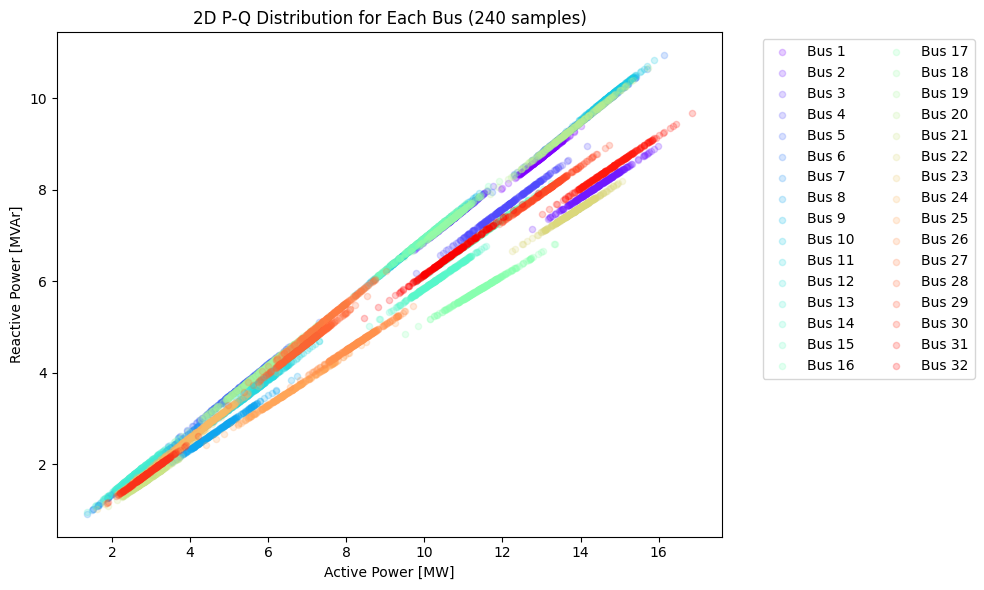

In [3]:
########################################
# Example: High-Dimensional Gaussian Loads
########################################
n_buses = len(net.bus) - 1  # exclude slack bus
mean_load = np.random.uniform(2, 15, size=n_buses)   # bus load means in MW
cov_load  = np.diag(np.random.uniform(0.1, 0.5, size=n_buses))  # diagonal covariance

# Generate N random samples
N = 240
active_power  = np.random.multivariate_normal(mean_load, cov_load, size=N)
active_power  = np.abs(active_power)  # ensure positivity

# Reactive power: Q = pf * P
power_factor   = np.random.uniform(0.5, 0.7, size=n_buses)
reactive_power = active_power * power_factor

########################################
# 2D P-Q DISTRIBUTION PLOT
########################################
plt.figure(figsize=(10, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, n_buses))

for i in range(n_buses):
    plt.scatter(active_power[:, i], reactive_power[:, i],
                color=colors[i], alpha=0.2, s=20, label=f'Bus {i+1}')

plt.title('2D P-Q Distribution for Each Bus (240 samples)')
plt.xlabel('Active Power [MW]')
plt.ylabel('Reactive Power [MVAr]')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

## Fitting a Conditional GMM on Bus Loads

We fit a **Gaussian Mixture Model** on the joint space of (bus loads, mean load). This lets us **conditionally sample** bus-level loads given a specified average load level.

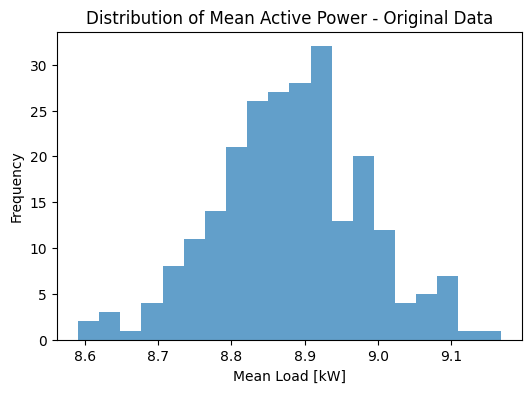

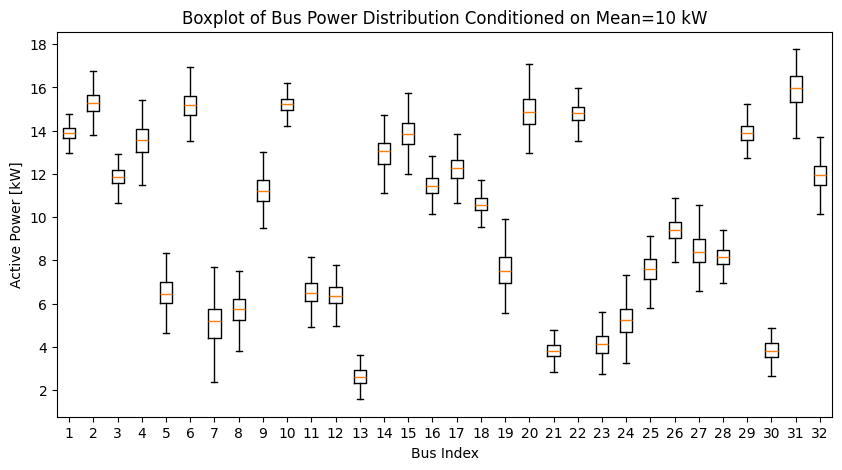

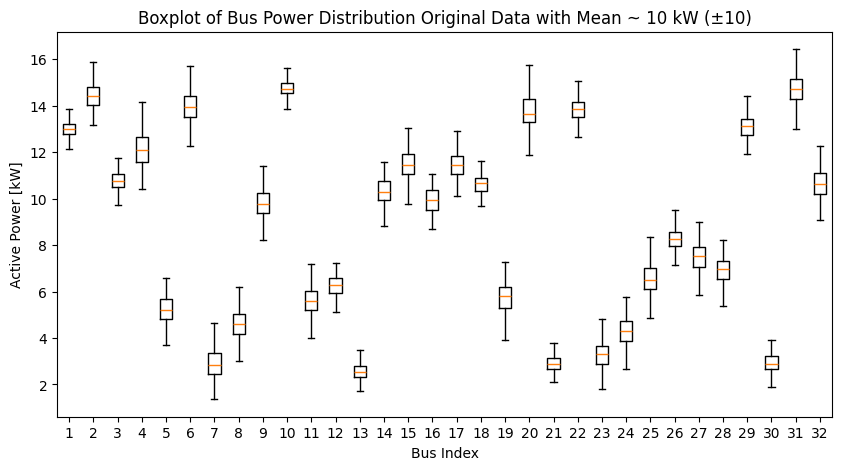

In [8]:

##########################
# USING A GAUSSIAN MIXTURE TO FIT THE LOAD CONDITION
#     ON TOTAL DAILY CONSUMPTION
##########################
# Suppose we treat "total consumption per day" as the sum across all buses.
# We'll fit a GMM on the daily sums from these samples.

# Assume you have the following data:
#   active_power: shape (N, n_buses), i.e. 240 x 33
# Each row is one "sample" (time instance); each column is a bus.

########################################
#  Prepare Data: Active Power + Mean
########################################
N, n_buses = active_power.shape
mean_active_power = active_power.mean(axis=1)

# Stack it as the last column → shape: (N, n_buses + 1)
X = np.hstack([active_power, mean_active_power.reshape(-1, 1)])

########################################
# Fit a GMM on the (n_buses + 1)-dimensional data
########################################
n_components = 2  # number of mixture components (example)
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)

########################################
# Define a function to sample from p(P | mean_load = M)
########################################
def sample_from_conditional_gmm(gmm, mean_value, n_samples=1):
    """
    Samples from the conditional distribution p(P_1, ..., P_n | mean_load = mean_value)
    given a fitted GMM in (n_buses + 1)-dimensional space.
    """
    d1 = gmm.means_.shape[1] - 1   # e.g. number of buses
    samples = np.zeros((n_samples, d1))

    # Arrays to store conditional parameters of each mixture component
    conditional_means = []
    conditional_covs = []
    mixture_weights = []

    for k in range(gmm.n_components):
        mu_k = gmm.means_[k]         # shape: (d1 + 1,)
        Sigma_k = gmm.covariances_[k]  # shape: (d1 + 1, d1 + 1)
        pi_k = gmm.weights_[k]

        # Partition mean vector
        mu_x1 = mu_k[:d1]           # shape: (d1,)
        mu_x2 = mu_k[d1:]           # shape: (1,)

        # Partition covariance
        Sigma_x1x1 = Sigma_k[:d1, :d1]    # (d1, d1)
        Sigma_x2x2 = Sigma_k[d1:, d1:]    # (1, 1)
        Sigma_x1x2 = Sigma_k[:d1, d1:]    # (d1, 1)
        Sigma_x2x1 = Sigma_k[d1:, :d1]    # (1, d1)

        sigma_x2x2 = Sigma_x2x2[0, 0]  # univariate

        # Conditional mean
        cond_mean = mu_x1 + (Sigma_x1x2[:, 0] / sigma_x2x2) * (mean_value - mu_x2[0])
        # Make sure cond_mean is 1D: shape (d1,)
        cond_mean = np.array(cond_mean, ndmin=1)

        # Conditional covariance
        #   Σ_x1|x2 = Σ_x1x1 - Σ_x1x2 Σ_x2x2^-1 Σ_x2x1
        # Note Sigma_x1x2 is (d1, 1), Sigma_x2x1 is (1, d1).
        cond_cov = Sigma_x1x1 - (Sigma_x1x2 @ Sigma_x2x1) / sigma_x2x2
        # Ensure shape is (d1, d1)
        cond_cov = np.atleast_2d(cond_cov)

        # Probability of X2 = mean_value in component k
        from math import sqrt, pi, exp
        def univariate_pdf(x, m, var):
            return 1 / np.sqrt(2 * pi * var) * np.exp(-0.5 * ((x - m) ** 2 / var))

        p_x2_given_k = univariate_pdf(mean_value, mu_x2[0], sigma_x2x2)
        mixture_weights.append(pi_k * p_x2_given_k)

        conditional_means.append(cond_mean)
        conditional_covs.append(cond_cov)

    # Normalize mixture weights
    mixture_weights = np.array(mixture_weights)
    mixture_weights /= mixture_weights.sum()

    # Sample from the conditional mixture distribution
    for i in range(n_samples):
        k_choice = np.random.choice(np.arange(gmm.n_components), p=mixture_weights)
        mean_k = conditional_means[k_choice]  # shape (d1,)
        cov_k = conditional_covs[k_choice]    # shape (d1, d1)

        # Draw a sample from the chosen (multivariate) normal
        samples[i, :] = np.random.multivariate_normal(mean_k, cov_k)

    return samples

########################################
# Plot the Distribution of mean_active_power (Original Data)
########################################
mean_active_power = active_power.mean(axis=1)
plt.figure(figsize=(6, 4))
plt.hist(mean_active_power, bins=20, alpha=0.7)
plt.title("Distribution of Mean Active Power - Original Data")
plt.xlabel("Mean Load [kW]")
plt.ylabel("Frequency")
plt.show()

########################################
# Conditional Samples from the GMM at mean_active_power
########################################
# Let's draw a larger set of conditional samples to visualize a distribution
num_conditional_samples_large = 500  # pick a larger number for better stats
sampled_target = 10
conditional_samples_large = sample_from_conditional_gmm(
    gmm,
    mean_value=sampled_target,
    n_samples=num_conditional_samples_large
)
conditional_samples_large = np.abs(conditional_samples_large)

# Boxplot of the bus-level power across the conditional samples
plt.figure(figsize=(10, 5))
plt.boxplot(conditional_samples_large, showfliers=False)
plt.title(f"Boxplot of Bus Power Distribution Conditioned on Mean={sampled_target} kW")
plt.xlabel("Bus Index")
plt.ylabel("Active Power [kW]")
plt.show()

########################################
# Plot Power Distribution of Original Data with Mean ~ 0.10
########################################
# Filter original dataset
tolerance = 10
mask = (mean_active_power >= sampled_target - tolerance) & (mean_active_power <= sampled_target + tolerance)
similar_data = active_power[mask]  # shape = (M, n_buses), M depends on how many rows match

# If we have at least one row matching:
if len(similar_data) > 0:
    plt.figure(figsize=(10, 5))
    plt.boxplot(similar_data, showfliers=False)
    plt.title(f"Boxplot of Bus Power Distribution Original Data with Mean ~ {sampled_target} kW (±{tolerance})")
    plt.xlabel("Bus Index")
    plt.ylabel("Active Power [kW]")
    plt.show()
else:
    print(f"No original samples found with mean load in [{sampled_target - tolerance}, {sampled_target + tolerance}].")

## Task 1: Sampling Load Data from the Conditional GMM

We call `sample_from_conditional_gmm(...)` **twice**: once for a **lower** mean load scenario (6 MW/bus) and once for a **higher** mean load scenario (10 MW/bus), generating 200 scenarios each.

In [6]:
##########################
# CHOOSE SCENARIOS
##########################
lower_mean_value  = 6   # MW per bus — lower load scenario
higher_mean_value = 10  # MW per bus — higher load scenario
num_samples       = 200 # number of scenarios per mean load

##########################
# TASK 1 SOLUTION: Sample loads from the conditional GMM
##########################
loads_lower  = sample_from_conditional_gmm(gmm, lower_mean_value,  n_samples=num_samples)
loads_higher = sample_from_conditional_gmm(gmm, higher_mean_value, n_samples=num_samples)

# Ensure non-negative loads
loads_lower  = np.abs(loads_lower)
loads_higher = np.abs(loads_higher)

print('Mean of lower loads:  ', loads_lower.mean().round(3),  'MW')
print('Mean of higher loads: ', loads_higher.mean().round(3), 'MW')

Mean of lower loads:   6.193 MW
Mean of higher loads:  10.0 MW


## Task 2: Voltage Computation Function

The function `run_dc_scenarios_and_get_angles_and_voltages(...)` loops over all load scenarios. For each scenario it:
1. Assigns the synthetic loads to `input_data_pgm`.
2. Creates a fresh `PowerGridModel`.
3. **Runs the power flow** (`calculate_power_flow()`).
4. Extracts per-unit bus voltages.

In [9]:
##########################
# TASK 2 SOLUTION: Complete the voltage computation function
##########################
def run_dc_scenarios_and_get_angles_and_voltages(load_matrix):
    """
    Runs a power flow for each row (scenario) in load_matrix.
    Returns voltage magnitudes in p.u. for all 33 buses across all scenarios.
    """
    num_scenarios, _ = load_matrix.shape
    voltage_results  = np.zeros((num_scenarios, 33))
    power_factor     = 0.3

    for i in range(num_scenarios):
        # Update active and reactive load for each bus
        input_data_pgm['sym_load']['p_specified'][:32] = load_matrix[i, :32] * 1000  # kW → W
        input_data_pgm['sym_load']['q_specified']      = (
            input_data_pgm['sym_load']['p_specified'] * power_factor
        )

        # Instantiate a fresh PowerGridModel with updated loads
        newpgm = PowerGridModel(input_data=input_data_pgm, system_frequency=50.0)

        # TASK 2: Run the power flow calculation
        newoutput = newpgm.calculate_power_flow()

        voltage_results[i, :] = newoutput['node']['u_pu']

    return voltage_results

## Task 3: Voltage Scenario Generation and Visualization

We run the power flow for all 200 lower-load and 200 higher-load scenarios and visualize the voltage distributions as **boxplots** across all 33 buses.

Mean voltage — lower load scenario  (p.u.): 0.9976
Mean voltage — higher load scenario (p.u.): 0.996


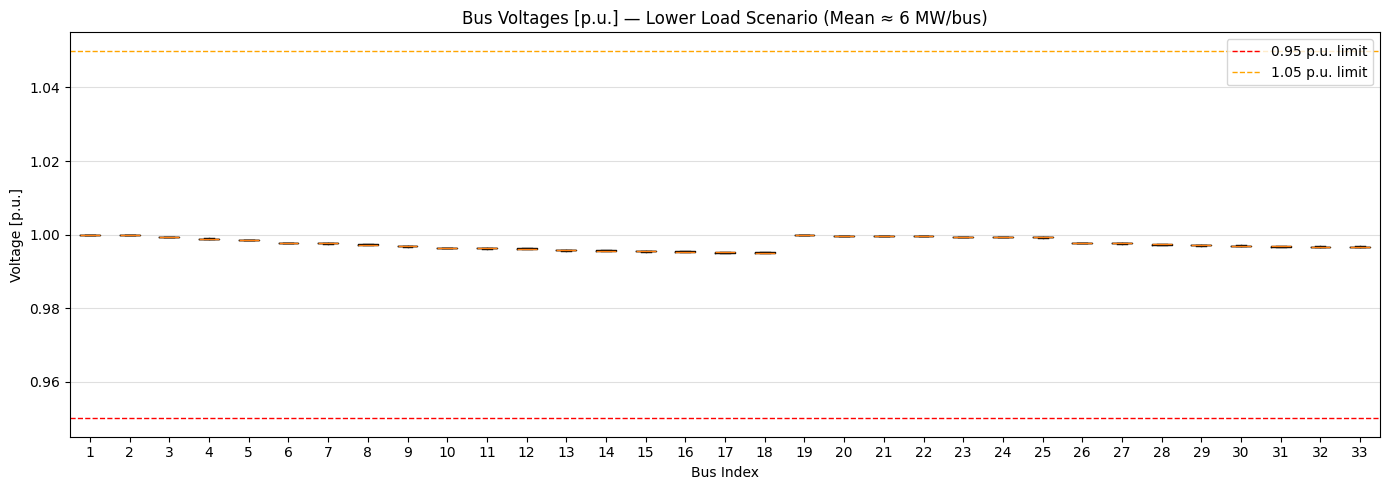

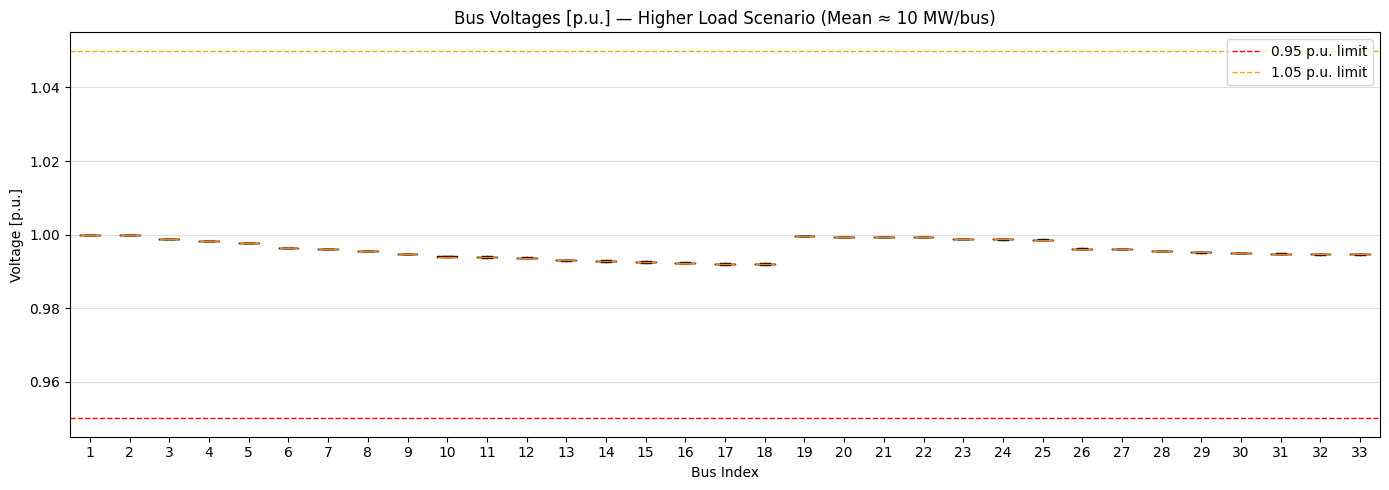

In [10]:
##########################
# TASK 3 SOLUTION: Run power flow and collect voltages
##########################
voltages_lower  = run_dc_scenarios_and_get_angles_and_voltages(loads_lower)
voltages_higher = run_dc_scenarios_and_get_angles_and_voltages(loads_higher)

print('Mean voltage — lower load scenario  (p.u.):', voltages_lower.mean().round(4))
print('Mean voltage — higher load scenario (p.u.):', voltages_higher.mean().round(4))

##########################
# BOXPLOT: Lower load
##########################
plt.figure(figsize=(14, 5))
plt.boxplot(voltages_lower, showfliers=False)
plt.axhline(0.95, color='red',    linestyle='--', linewidth=1, label='0.95 p.u. limit')
plt.axhline(1.05, color='orange', linestyle='--', linewidth=1, label='1.05 p.u. limit')
plt.title(f'Bus Voltages [p.u.] — Lower Load Scenario (Mean ≈ {lower_mean_value} MW/bus)')
plt.xlabel('Bus Index')
plt.ylabel('Voltage [p.u.]')
plt.legend()
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

##########################
# BOXPLOT: Higher load
##########################
plt.figure(figsize=(14, 5))
plt.boxplot(voltages_higher, showfliers=False)
plt.axhline(0.95, color='red',    linestyle='--', linewidth=1, label='0.95 p.u. limit')
plt.axhline(1.05, color='orange', linestyle='--', linewidth=1, label='1.05 p.u. limit')
plt.title(f'Bus Voltages [p.u.] — Higher Load Scenario (Mean ≈ {higher_mean_value} MW/bus)')
plt.xlabel('Bus Index')
plt.ylabel('Voltage [p.u.]')
plt.legend()
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

 **Task 4: Analysis of probabilistic power flow simulations.**

Answer the next questions based on the lecture content and your results:

- What is the added value of a probabilistic power flow simulation analysis,  - - when compared with a deterministic simulation?
- How can this added value be exploited when planning modern power (distribution) systems?
- So far, we have focused on a technical analysis, disregarding any financial aspect. How a probabilistic power flow simulation analysis can also be used when performing a financial analysis in distribution systems planning?